# AI Crypto Hedge Fund - Final Notebook

Execution mode: **FULL FINAL NOTEBOOK**.

This notebook is the single end-to-end reviewer narrative. It imports repository
package code and reads committed validation/final-test artifacts. It does not place
orders, download live data, call an external LLM or rerun/tune final-test strategies.


In [210]:
import os
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Cannot locate repository root from notebook working directory.")


ROOT = find_repo_root(Path.cwd().resolve())
EXPECTED_VENV = (ROOT / ".venv").resolve()
RUNNING_PYTHON = Path(sys.executable).resolve()
RUNNING_PREFIX = Path(sys.prefix).resolve()
if RUNNING_PREFIX != EXPECTED_VENV:
    raise RuntimeError(
        "This notebook must run with the repository uv environment. "
        f"Run `uv sync --frozen`, then select {EXPECTED_VENV / 'bin/python'} "
        f"or run `make notebook-full`. Current interpreter: {RUNNING_PYTHON}; "
        f"current sys.prefix: {RUNNING_PREFIX}"
    )
os.chdir(ROOT)

from IPython.display import display

from crypto_hedge_fund.reporting import load_stage12_context
from crypto_hedge_fund.reporting.context import (
    representative_trace_rows,
)
from crypto_hedge_fund.reporting.notebook_display import (
    benchmark_frame,
    candidate_results_frame,
    commands_frame,
    configure_notebook_display,
    key_value_frame,
    leakage_evidence_frame,
    level1_agent_evolution_frame,
    level3_assets_frame,
    level3_method_frame,
    level4_policy_frame,
    level5_diagnostics_frame,
    level5_mechanics_frame,
    model_spec_frame,
    monitoring_incident_frame,
    plot_level5_cost_decomposition,
    plot_predictive_auc,
    plot_return_overview,
    plot_selected_drawdowns,
    plot_selected_nav,
    predictive_metrics_frame,
    reproducibility_frame,
    robustness_frame,
    selected_summary_frame,
    selected_validation_final_frame,
    selection_rationale_frame,
    short_hash,
    show_frame,
    target_features_frame,
    trace_frame,
)

configure_notebook_display()
ctx = load_stage12_context(ROOT)
display(
    show_frame(
        key_value_frame(
            [
                ("Final-test lock", short_hash(ctx.lock_hash)),
                ("Final-test exposure", ctx.suite_summary["final_test_exposure"]),
                ("Final-test dir", ctx.final_dir.relative_to(ROOT).as_posix()),
                ("Notebook mode", "FULL FINAL NOTEBOOK"),
            ]
        ),
        caption="Notebook execution context",
    )
)

Metric,Value
Final-test lock,c33b5eb396f6...43af5e
Final-test exposure,EXPOSED
Final-test dir,artifacts/final_test/c33b5eb396f6
Notebook mode,FULL FINAL NOTEBOOK


## 1. Executive summary

This is a reproducible historical research MVP for an AI-assisted crypto fund
workflow. It is long-only, unlevered, daily spot, USDT-cash based, educational and
does not enable live order submission. Net results after fees and slippage are the
primary evidence.


In [211]:
display(
    show_frame(
        selected_summary_frame(ctx),
        caption="Frozen final selected results",
    )
)
display(
    show_frame(
        selected_validation_final_frame(ctx),
        caption="Validation versus final",
    )
)

Level,Selected,Net,Bench,Sharpe,MDD,Cost
level_1,SMA baseline,-7.4%,-5.4%,-0.171,-18.5%,"$8,906"
level_2,Ensemble,-0.6%,-5.4%,-0.522,-1.4%,"$1,600"
level_3,CVaR,-18.0%,-25.4%,-0.023,-45.2%,"$1,493"
level_4,Calendar,-4.1%,-9.3%,-0.880,-9.1%,"$3,584"
level_5,Large universe,-28.0%,-45.2%,-0.218,-42.2%,"$110,939"


Level,Split,Selected,Net,Bench,Sharpe,MDD
Level 1,Validation,SMA 30/100,118.6%,119.0%,1.954,-20.0%
Level 1,Final,SMA 30/100,-7.4%,-5.4%,-0.171,-18.5%
Level 2,Validation,Ensemble,2.8%,119.0%,1.110,-2.3%
Level 2,Final,Ensemble,-0.6%,-5.4%,-0.522,-1.4%
Level 3,Validation,CVaR,126.1%,128.1%,1.696,-34.7%
Level 3,Final,CVaR,-18.0%,-25.4%,-0.023,-45.2%
Level 4,Validation,Calendar,3.4%,63.9%,0.475,-6.6%
Level 4,Final,Calendar,-4.1%,-9.3%,-0.880,-9.1%
Level 5,Validation,large_universe_dynamic,-18.6%,-7.1%,-4.239,-18.8%
Level 5,Final,large_universe_dynamic,-28.0%,-45.2%,-0.218,-42.2%


## 2. Reproducibility, data and benchmark definitions

The accepted lock freezes validation-selected methodology before final-test exposure.
This notebook reads committed artifacts; it does not rerun `make final-test` or
retune any final-year decision. Public repository visibility must still be verified by
the human owner.


In [212]:
display(
    show_frame(
        reproducibility_frame(ctx),
        caption="Reproducibility and provenance",
    )
)
display(show_frame(commands_frame(), caption="Reviewer runbook"))
display(show_frame(benchmark_frame(ctx), caption="Benchmark definitions"))

Metric,Value
Python,3.11
Package manager,uv with committed uv.lock
Final-test period,2025-01-01 to 2025-12-31
Train/validation,"2021-2023 train, 2024 validation"
Final-test lock,c33b5eb396f6...43af5e
Data SHA-256,9f539f383942...0d7e14
Validation config,da1dcaf44251...2e77e8
Locked commit,d200df6d8a5b...43a1e5
Runner commit,d200df6d8a5b...43a1e5
Base tag,stage/09-level-5-100pairs


Step,Command
Setup,uv sync --frozen
Data,make validate-data
Quality,make lint && make test
Notebook,make notebook-full
Deck,make presentation
Release,make release-verify
Do not rerun,make final-test after exposure


Scope,Benchmark definition
Level 3,broker_costed_equal_weight_static_basket
Level 4,broker_costed_level3_static_benchmark
Level 5,broker_costed_equal_weight_top_k_universe
Levels 1-2,broker_costed_buy_and_hold


## 3. Architecture and causal clock

Shared pipeline: frozen OHLCV -> validation gate -> causal features -> typed agents
-> aggregator -> pre-risk -> allocator -> rebalance controller -> post-risk ->
orders/fills -> ledger -> metrics and monitoring. Features use completed daily bars;
execution is at the next available open.


In [213]:
trace_rows = representative_trace_rows(ctx)
display(show_frame(trace_frame(trace_rows), caption="Representative Level 2 agent trace"))

Agent,Score,Conf,Fit,Action
sma_crossover,-1.000,0.228,2024-12-31,ok
econometric_ar_garch,0.037,0.049,2024-12-31,ok
ml_logistic,-0.128,0.128,2024-12-31,ok
ml_hist_gradient_boosting,-0.236,0.236,2024-12-31,ok
aggregator,-0.466,0.040,2024-12-31,ok
post_risk,approve,cash=100.0%,2025-01-01,ok


## 4. Level 1 — Baseline Strategy for a Single Cryptocurrency.

Level 1 is a one-symbol configuration of the same broker, risk and ledger engine used
by the later levels. The baseline is intentionally simple, then wrapped into the
agent interface used by Level 2.


In [214]:
display(
    show_frame(
        level1_agent_evolution_frame(ctx),
        caption="SMA baseline and agent evolution",
    )
)
display(
    show_frame(
        candidate_results_frame(ctx, "level_1", split="validation"),
        caption="Level 1 validation",
    )
)
display(
    show_frame(
        candidate_results_frame(ctx, "level_1", split="final"),
        caption="Level 1 final",
    )
)

Metric,Value
Rule,"BTC/USDT SMA fast=30, slow=100"
Execution,completed close signal; next-open broker execution
Agent evolution,SMA rule -> typed SignalAgent -> score/confidence -> ensemble input
Risk layer,pre/post risk controls decide final exposure and can move to cash


Net,Sharpe,MDD,Turn,Cost,Bench
118.6%,1.954,-20.0%,500.5%,"$10,771",119.0%


Net,Sharpe,MDD,Turn,Cost,Bench
-7.4%,-0.171,-18.5%,598.7%,"$8,906",-5.4%


## 5. Level 2 — Adding AI Agents, Econometrics and ML.

Level 2 adds technical, econometric and ML agents on BTC/USDT. The ensemble was frozen
as the assignment-representative multi-agent candidate with acceptable validation risk
and turnover; it was not selected as the unconditional maximum-performance row.


In [215]:
display(show_frame(model_spec_frame(ctx), caption="Model specification"))
display(show_frame(target_features_frame(ctx), caption="Target, features and retraining cadence"))
display(show_frame(leakage_evidence_frame(ctx), caption="No-leakage fit audit"))

Model,Preprocessing,Parameters,Refit
SMA,completed close history,10/50 in Level 2; 30/100 in Level 1,rule-based
AutoReg/GARCH,open returns,"AutoReg + GARCH(1,1)",daily_causal
Logistic Regression,median imputer + StandardScaler,max_iter=500; class_weight=balanced,monthly expanding
HistGradientBoosting,median imputer,60 iter; LR 0.05; 15 leaves; L2 0.01,monthly expanding


Metric,Value
Target,1[open(t+2) / open(t+1) - 1 > 0.0005]
Feature groups,"returns, momentum, trend, RSI/MACD, ATR/range, vol, drawdown, volume"
Causal clock,completed daily bars; decisions execute at next open
ML retraining,monthly
Econometric refit,daily_causal
Agent weights,"{""econometric"": 0.25, ""hist_gradient_boosting"": 0.25, ""logistic"": 0.25, ""technical"": 0.25}"


Metric,Value
Fit-audit rows,"2,548"
Prediction rows,"1,092"
Future-label flags,0
Audit status,ok
ML refit,"daily_causal, monthly"
Feature cutoff example,2025-01-01
Fit cutoff example,2024-12-31


## 6. Level 2 - validation, predictive metrics and robustness

Validation and final evidence are shown separately to make the selection discipline
explicit. Predictive metrics demonstrate the main research result: validation signal
did not generalize reliably in the exposed final year.


Approach,Selected,Net,Sharpe,MDD,Turn,Cost,Bench
SMA,no,45.2%,1.133,-34.3%,1338.5%,"$23,529",119.0%
AR/GARCH,no,2.7%,0.588,-3.4%,2418.0%,"$37,110",119.0%
Logistic,no,1.4%,1.415,-0.3%,237.2%,"$3,591",119.0%
HGB,no,2.8%,1.353,-1.0%,576.7%,"$8,800",119.0%
Ensemble,yes,2.8%,1.110,-2.3%,263.7%,"$4,019",119.0%


Approach,Selected,Net,Sharpe,MDD,Turn,Cost,Bench
SMA,no,-7.9%,-0.383,-18.9%,915.6%,"$13,915",-5.4%
AR/GARCH,no,-3.7%,-1.411,-4.1%,2033.8%,"$29,711",-5.4%
Logistic,no,-0.4%,-0.602,-0.6%,193.6%,"$2,900",-5.4%
HGB,no,0.0%,0.020,-1.3%,462.3%,"$6,947",-5.4%
Ensemble,yes,-0.6%,-0.522,-1.4%,106.5%,"$1,600",-5.4%


Model,Split,ROC-AUC,PR-AUC,Log loss,Brier
Logistic,Validation,0.542,0.545,0.689,0.248
HGB,Validation,0.586,0.558,0.690,0.248
Logistic,Final,0.515,0.501,0.689,0.248
HGB,Final,0.497,0.453,0.706,0.256


Metric,Value
Bootstrap reps,1000
Bootstrap block,14 days
Sharpe 95% CI,-2.30 to 1.42
Shift randomization p-value,0.984
Score/forward-return corr,-0.0021
Recorded net ROI,-0.6%


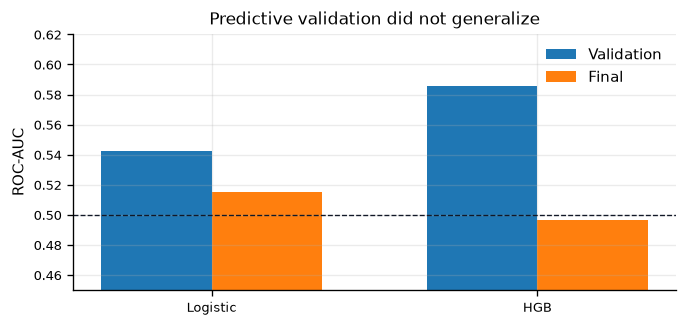

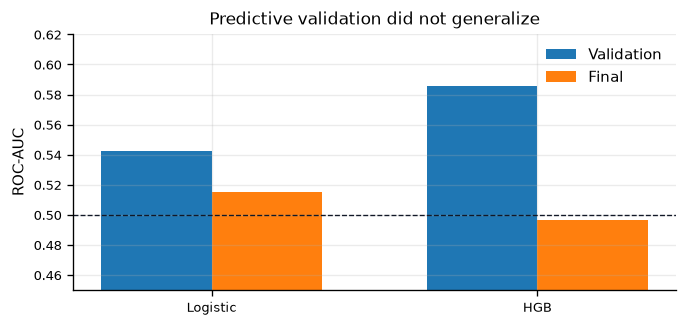

In [216]:
display(
    show_frame(
        candidate_results_frame(ctx, "level_2", split="validation"),
        caption="Level 2 validation candidates",
    )
)
display(
    show_frame(
        candidate_results_frame(ctx, "level_2", split="final"),
        caption="Level 2 final candidates",
    )
)
display(
    show_frame(
        predictive_metrics_frame(ctx),
        caption="Predictive metrics",
    )
)
display(
    show_frame(
        robustness_frame(ctx),
        caption="Robustness and randomness checks",
    )
)
plot_predictive_auc(ctx)

## 7. Level 3 — Portfolio Management on Historical Data.

Level 3 uses a frozen 5-7 asset universe and an exact trailing 12-month final
estimation window. Candidate methods are compared on validation; the final 2025 run
executes the frozen method without switching to a better-looking final comparator.


In [217]:
display(
    show_frame(
        level3_method_frame(ctx),
        caption="Level 3 construction and trading path",
    )
)
display(show_frame(level3_assets_frame(ctx), caption="Selected CVaR weights"))
display(
    show_frame(
        candidate_results_frame(ctx, "level_3", split="validation"),
        caption="Level 3 validation candidates",
    )
)
display(
    show_frame(
        candidate_results_frame(ctx, "level_3", split="final"),
        caption="Level 3 final candidates",
    )
)

Metric,Value
Final assets,"BTC/USDT, ETH/USDT, SOL/USDT, PEPE/USDT, BNB/USDT, XRP/USDT, DOGE/USDT"
Estimation window,2024-01-01 to 2024-12-31
Candidate methods,"equal_weight, inverse_volatility, minimum_variance, cvar_downside"
Selected method,cvar_downside
Objective,validation net Sharpe; risk/cost metrics reported net of fees/slippage
Trading application,target weights -> risk approval -> next-open orders/fills -> ledger


Symbol,Weight
BTC/USDT,19.8%
BNB/USDT,18.2%
ETH/USDT,15.7%
XRP/USDT,13.4%
SOL/USDT,12.9%
DOGE/USDT,10.8%
PEPE/USDT,8.7%


Method,Selected,Net,Sharpe,MDD,Turn,Cost,Bench
Equal weight,no,128.1%,1.676,-36.3%,99.5%,"$1,492",128.1%
Inv vol,no,121.8%,1.667,-35.2%,99.5%,"$1,492",128.1%
Min var,no,111.4%,1.653,-32.8%,99.5%,"$1,492",128.1%
CVaR,yes,126.1%,1.696,-34.7%,99.5%,"$1,492",128.1%


Method,Selected,Net,Sharpe,MDD,Turn,Cost,Bench
Equal weight,no,-25.4%,-0.125,-48.7%,99.5%,"$1,492",-25.4%
Inv vol,no,-16.4%,0.002,-44.8%,99.5%,"$1,493",-25.4%
Min var,no,0.9%,0.280,-36.3%,99.5%,"$1,493",-25.4%
CVaR,yes,-18.0%,-0.023,-45.2%,99.5%,"$1,493",-25.4%


## 8. Level 4 — Dynamic Portfolio Rebalancing.

Calendar monthly was the frozen selected policy. Drift and signal/risk policies can
show better final return, but the post-exposure rule is strict: do not replace the
selected policy after seeing final-year results.


In [218]:
display(show_frame(level4_policy_frame(ctx), caption="Level 4 policy mechanics"))
display(
    show_frame(
        candidate_results_frame(ctx, "level_4", split="validation"),
        caption="Level 4 validation candidates",
    )
)
display(
    show_frame(
        candidate_results_frame(ctx, "level_4", split="final"),
        caption="Level 4 final candidates",
    )
)

Policy,Calendar,Drift,Score trigger,Risk trigger
calendar_monthly,monthly,100.0%,100.0%,no
drift_monthly,monthly,5.0%,100.0%,no
signal_risk_monthly,monthly,5.0%,15.0%,yes


Policy,Selected,Net,Sharpe,MDD,Turn,Cost,Bench
Static,no,126.1%,1.696,-34.7%,99.5%,"$1,492",126.1%
Calendar,yes,3.4%,0.475,-6.6%,182.0%,"$2,763",63.9%
Drift,no,55.1%,1.513,-22.8%,931.7%,"$13,040",63.9%
Signal/risk,no,55.1%,1.513,-22.8%,931.7%,"$13,040",63.9%


Policy,Selected,Net,Sharpe,MDD,Turn,Cost,Bench
Static,no,-18.0%,-0.023,-45.2%,99.5%,"$1,493",-18.0%
Calendar,yes,-4.1%,-0.880,-9.1%,237.3%,"$3,584",-9.3%
Drift,no,3.8%,0.290,-23.5%,839.0%,"$12,733",-9.3%
Signal/risk,no,3.8%,0.290,-23.5%,839.0%,"$12,733",-9.3%


## 9. Level 5 — Portfolio Expansion to 100+ Pairs.

Level 5 is a deterministic cross-sectional quant scoring agent, not a fitted ML
model. It proves the 100+ pair requirement and records operational health beyond
trading KPIs.


In [219]:
display(show_frame(level5_mechanics_frame(ctx), caption="Level 5 mechanics"))
display(
    show_frame(
        candidate_results_frame(ctx, "level_5", split="validation"),
        caption="Level 5 validation summary",
    )
)
display(
    show_frame(
        candidate_results_frame(ctx, "level_5", split="final"),
        caption="Level 5 final summary",
    )
)
display(
    show_frame(
        monitoring_incident_frame(ctx),
        caption="Monitoring and incidents",
    )
)

Question,Implementation
Pair selection,USDT spot; history/liquidity filters; excludes stable/fiat bases
Signal priority,deterministic cross-sectional factor score
Factors,"20/60-day momentum, vol, drawdown, liquidity penalties"
Portfolio,top 25; max 5%; inverse_volatility allocation
Rebalance,weekly plus drift/signal/risk; score trigger 10%
Risk,"pre/post gates, cash approval, caps, turnover checks"
Monitoring,"runtime, RSS, incidents, fallback, nulls, pair counts"
Fail-safe,"abstain, retain weights, move to cash, kill switch evidence"


Net,Sharpe,MDD,Turn,Cost,Bench
-18.6%,-4.239,-18.8%,346.3%,"$5,216",-7.1%


Net,Sharpe,MDD,Turn,Cost,Bench
-28.0%,-0.218,-42.2%,4924.5%,"$110,939",-45.2%


Metric,Value
System status,ok
Recorded monitoring events,53
Critical alerts,0
Warning alert rows,2
Info alert rows,2
Invalid data count,0
Invalid model count,0
Optimizer fallback rate,14.5%
Abstention rate,0.0%
Fail-safe evidence,"kill_switch_cash_schedule_unit_test, volatility_limit_cash_approval, invalid_feature_alert_path, weight_reconciliation_post_risk"


## 10. Level 5 economics and cross-level diagnostics

Scalable processing was achieved, but the factor policy produced negative gross
performance and very high turnover. Costs materially worsened the result. This is a
central research conclusion, not a hidden failure.


Metric,Value
Gross return,-18.6%
Return drag from costs,9.4% gross-to-net
Net return,-28.0%
Benchmark,-45.2%
Rebalance decisions,364
Fills,"8,727"
Fee-bearing notional,"$73,959,230"
Total cost,"$110,939"
Cost as % initial AUM,11.1%
Average cash,14.7%


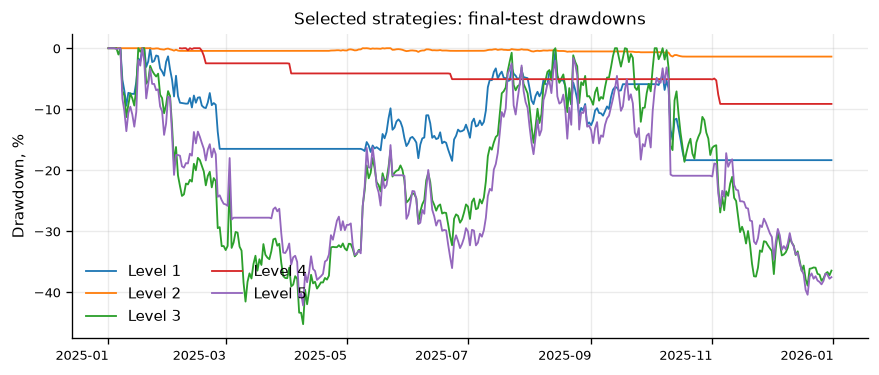

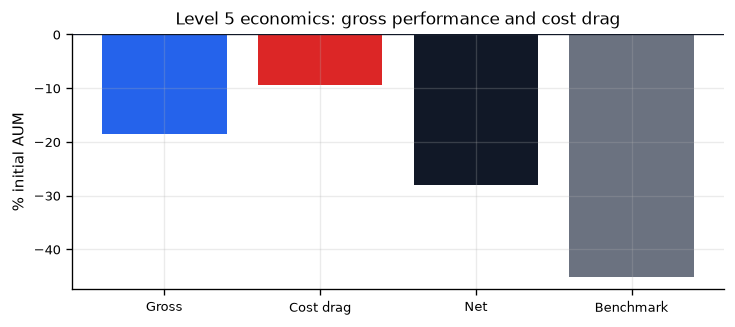

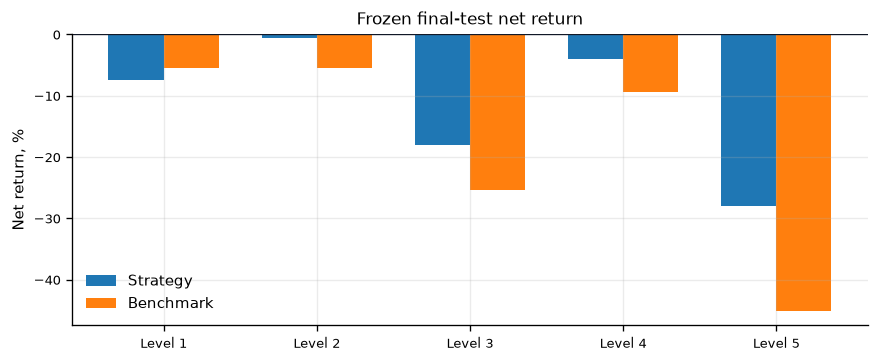

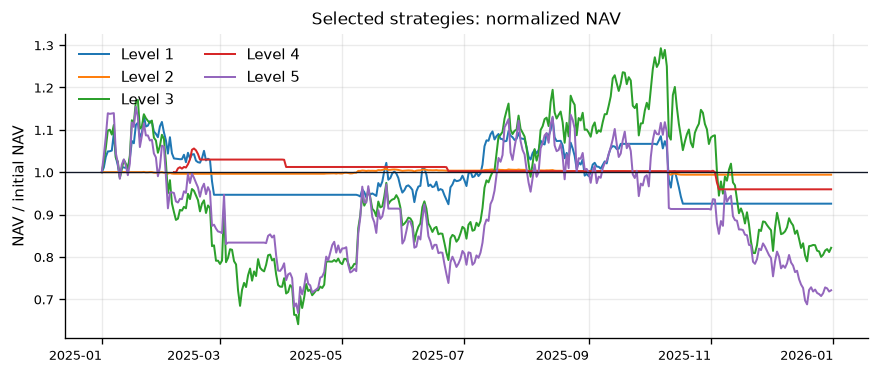

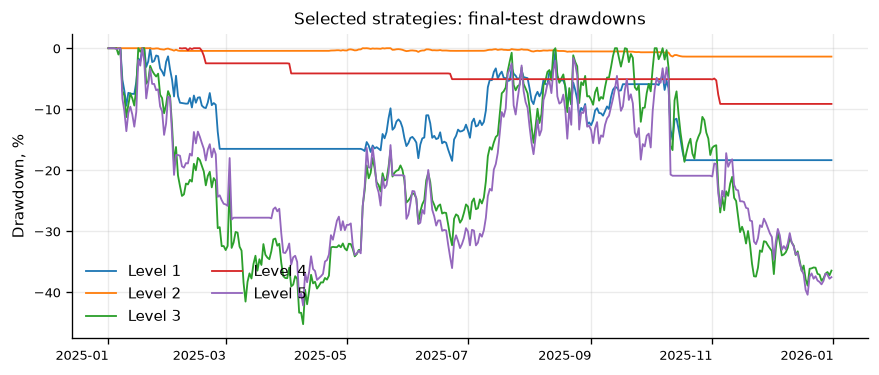

In [220]:
display(
    show_frame(
        level5_diagnostics_frame(ctx),
        caption="Level 5 cost and turnover",
    )
)
plot_level5_cost_decomposition(ctx)
plot_return_overview(ctx)
plot_selected_nav(ctx)
plot_selected_drawdowns(ctx)

## 11. Selection rationale, limitations and roadmap

The final suite is exposed, so the only allowed changes are presentation, explanation
and visualization of already-frozen artifacts. Limitations: active-market
survivorship/delisting bias, daily-bar liquidity proxies, USDT cash assumption,
simplified fills, cash-heavy risk behavior and Level 5 top-K benchmark rather than a
full eligible-universe benchmark. Future work includes multi-CEX adapters,
order-book liquidity, reconciliation, Telegram controls and news/sentiment ingestion;
those future items are not enabled in this MVP.


In [221]:
display(
    show_frame(
        selection_rationale_frame(ctx),
        caption="Validation-selected methodology",
    )
)

Level,Frozen selection,Rationale
1,SMA 30/100 BTC,validation net Sharpe among SMA grid; typed SignalAgent wrapper
2,Ensemble,"multi-agent candidate; acceptable risk, not max-performance row"
3,cvar_downside,maximum validation net Sharpe in static portfolio candidates
4,calendar_monthly,"validation selected under MDD <= 25%, turnover <= 6.0"
5,top-25 inv-vol universe,cross-sectional scoring; validates >=100 pairs and fail-safes
